<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/LSTM/Time_series_forecasting_with_LSTM_for_uni_multivar_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Time series weather forecasting
**Objective**: forecasting a univariate time series

In [ ]:
import tensorflow as tf
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

##The weather dataset
We are using weather time series dataset from Max Planck Institute for Biogeochemistry.

This dataset contains 14 different features such as air temperature, atmospheric pressure, and humidity. With frequency of 10 minutes, beginning in 2003. From François Chollet for his book Deep Learning with Python.

In [ ]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
csv_path

'/root/.keras/datasets/jena_climate_2009_2016_extracted'

In [ ]:
path=csv_path+'/jena_climate_2009_2016.csv'

In [ ]:
df = pd.read_csv(path)
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


As you can see above, an observation is recorded every 10 minutes. This means that, for a single hour, you will have 6 observations. Similarly, a single day will contain 144 (6x24) observations.

Given a specific time, let's say you want to predict the temperature 6 hours in the future. In order to make this prediction, you choose to use 5 days of observations. Thus, you would create a window containing the last 720(5x144) observations to train the model. Many such configurations are possible, making this dataset a good one to experiment with.

The function below returns the above described windows of time for the model to train on. The parameter history_size is the size of the past window of information. The target_size is how far in the future does the model need to learn to predict. The target_size is the label that needs to be predicted.

In [ ]:
def univariate_data(dataset, start_index, end_index, history_size, target_size):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i)
    # Reshape data from (history_size,) to (history_size, 1)
    data.append(np.reshape(dataset[indices], (history_size, 1)))
    labels.append(dataset[i+target_size])
  return np.array(data), np.array(labels)

In both the following tutorials, the first 300,000 rows of the data will be the training dataset, and there remaining will be the validation dataset. This amounts to ~2100 days worth of training data.

In [ ]:
TRAIN_SPLIT = 300000
tf.random.set_seed(13) #Setting seed to ensure reproducibility

##Part 1: Forecast a univariate time series
First, you will train a model using only a single feature (temperature), and use it to make predictions for that value in the future.

Let's first extract only the temperature from the dataset.

In [ ]:
uni_data = df['T (degC)']
uni_data.index = df['Date Time']
uni_data

,T (degC)
Date Time,
01.01.2009 00:10:00,-8.02
01.01.2009 00:20:00,-8.41
01.01.2009 00:30:00,-8.51
01.01.2009 00:40:00,-8.31
01.01.2009 00:50:00,-8.27
...,...
31.12.2016 23:20:00,-4.05
31.12.2016 23:30:00,-3.35
31.12.2016 23:40:00,-3.16


Let's observe how this data looks across time.

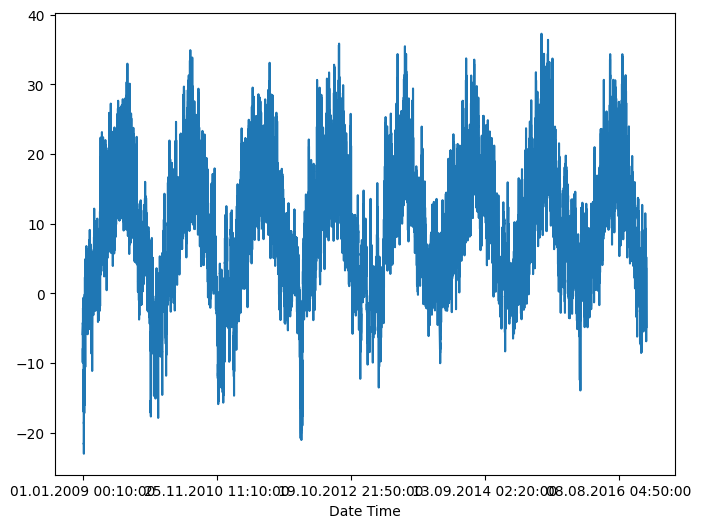

In [ ]:
uni_data.plot(subplots=True)
plt.show()

In [ ]:
uni_data = uni_data.values
uni_data

array([-8.02, -8.41, -8.51, ..., -3.16, -4.23, -4.82])

It is important to scale features before training a neural network. Standardization is a common way of doing this scaling by subtracting the mean and dividing by the standard deviation of each feature.You could also use a tf.keras.utils.normalize method that rescales the values into a range of [0,1].

Note: The mean and standard deviation should only be computed using the training data.

In [ ]:
uni_train_mean = uni_data[:TRAIN_SPLIT].mean()
uni_train_std = uni_data[:TRAIN_SPLIT].std()

In [ ]:
uni_train_mean

np.float64(9.233256299999999)

In [ ]:
uni_train_std

np.float64(8.636720398054864)

In [ ]:
# Let's standardize the data.
uni_data = (uni_data-uni_train_mean)/uni_train_std

In [ ]:
uni_data

array([-1.99766294, -2.04281897, -2.05439744, ..., -1.43494935,
       -1.55883897, -1.62715193])

In [ ]:
uni_data.mean()

np.float64(0.0251126636394392)

In [ ]:
uni_data.std()

np.float64(0.9752955760381984)

Let's now create the data for the univariate model. For part 1, the model will be given the last 20 recorded temperature observations, and needs to learn to predict the temperature at the next time step.

In [ ]:
univariate_past_history = 20
univariate_future_target = 0

x_train_uni, y_train_uni = univariate_data(uni_data, 0, TRAIN_SPLIT,
                                           univariate_past_history,
                                           univariate_future_target)
x_val_uni, y_val_uni = univariate_data(uni_data, TRAIN_SPLIT, None,
                                       univariate_past_history,
                                       univariate_future_target)

In [ ]:
print(x_train_uni.shape, y_train_uni.shape)

(299980, 20, 1) (299980,)


In [ ]:
print(x_val_uni.shape, y_val_uni.shape)

(120531, 20, 1) (120531,)


This is what the univariate_data function returns.

In [ ]:
print ('Single window of past history')
print (x_train_uni[0].reshape(-1))
print ('\n Target temperature to predict')
print (y_train_uni[0])

Single window of past history
[-1.99766294 -2.04281897 -2.05439744 -2.0312405  -2.02660912 -2.00113649
 -1.95134907 -1.95134907 -1.98492663 -2.04513467 -2.08334362 -2.09723778
 -2.09376424 -2.09144854 -2.07176515 -2.07176515 -2.07639653 -2.08913285
 -2.09260639 -2.10418486]

 Target temperature to predict
-2.1041848598100876


Now that the data has been created, let's take a look at a single example. The information given to the network is given in blue, and it must predict the value at the red cross.

In [ ]:
def create_time_steps(length):
  return list(range(-length, 0))

In [ ]:
def show_plot(plot_data, delta, title):
  labels = ['History', 'True Future', 'Model Prediction']
  marker = ['.-', 'rx', 'go']
  time_steps = create_time_steps(plot_data[0].shape[0])
  if delta:
    future = delta
  else:
    future = 0

  plt.title(title)
  for i, x in enumerate(plot_data):
    if i:
      plt.plot(future, plot_data[i], marker[i], markersize=10,
               label=labels[i])
    else:
      plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
  plt.legend()
  plt.xlim([time_steps[0], (future+5)*2])
  plt.xlabel('Time-Step')
  plt.show()
  #return plt

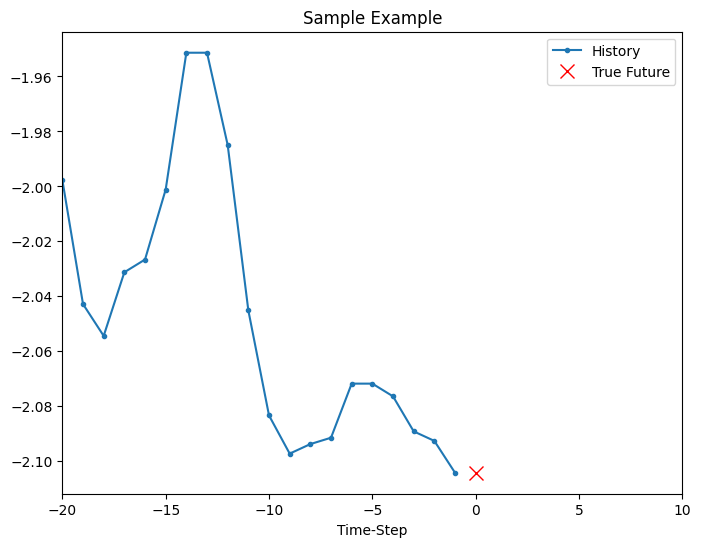

In [ ]:
show_plot([x_train_uni[0], y_train_uni[0]], 0, 'Sample Example')

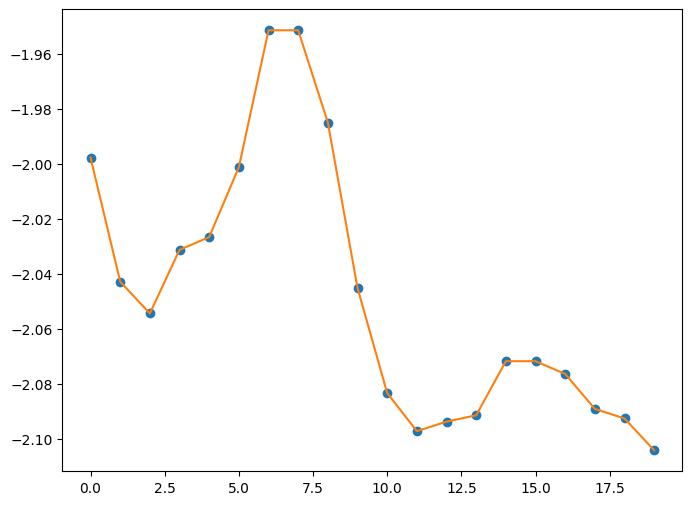

In [ ]:
plt.plot(x_train_uni[0],'o')
plt.plot(x_train_uni[0],'-')
plt.show()

###Baseline
Before proceeding to train a model, let's first set a simple baseline. Given an input point, the baseline method looks at all the history and predicts the next point to be the average of the last 20 observations.

In [ ]:
def baseline(history):
  return np.mean(history)

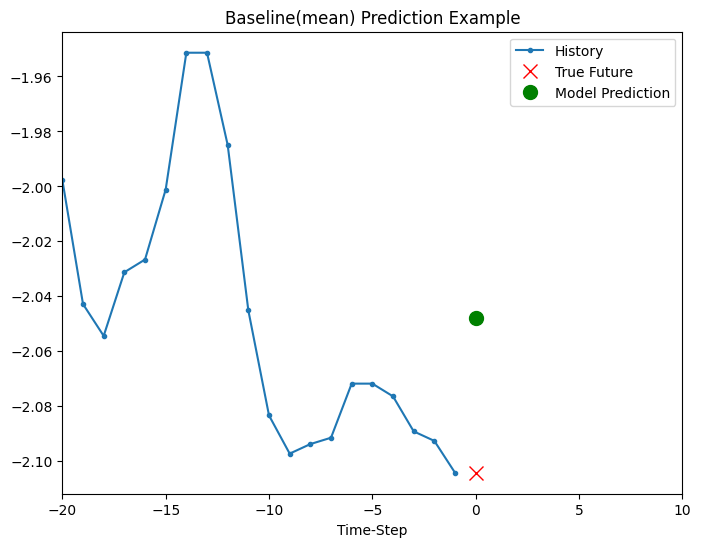

In [ ]:
show_plot([x_train_uni[0], y_train_uni[0], baseline(x_train_uni[0])], 0,
           'Baseline(mean) Prediction Example')

Let's see if you can beat this baseline using a recurrent neural network.

##Recurrent neural network
A Recurrent Neural Network (RNN) is a type of neural network well-suited to time series data. RNNs process a time series step-by-step, maintaining an internal state summarizing the information they've seen so far. For more details, read the RNN tutorial. In this tutorial, you will use a specialized RNN layer called Long Short Term Memory (LSTM)

Let's now use `tf.data` to shuffle, batch, and cache the dataset.

In [ ]:
BATCH_SIZE = 256
BUFFER_SIZE = 10000

train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni))
val_univariate = val_univariate.batch(BATCH_SIZE).repeat()

In [ ]:
train_univariate

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 20, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

You will see the LSTM requires the input shape of the data it is being given.

In [ ]:
tf.keras.backend.clear_session()

simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((x_train_uni.shape[-2:])),
    tf.keras.layers.LSTM(8),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='adam', loss='mae')
simple_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

Let's make a sample prediction, to check the output of the model.

In [ ]:
for x, y in val_univariate.take(1):
    print(simple_lstm_model.predict(x).shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
(256, 1)


Let's train the model now. Due to the large size of the dataset, in the interest of saving time, each epoch will only run for 200 steps, instead of the complete training data as normally done.

In [ ]:
EVALUATION_INTERVAL = 200
EPOCHS = 20

history = simple_lstm_model.fit(train_univariate, epochs=EPOCHS,
                      steps_per_epoch=EVALUATION_INTERVAL,
                      validation_data=val_univariate, validation_steps=50)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5510 - val_loss: 0.0791
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0795 - val_loss: 0.0322
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0416 - val_loss: 0.0265
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0386 - val_loss: 0.0232
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0258 - val_loss: 0.0215
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0286 - val_loss: 0.0202
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0262 - val_loss: 0.0192
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0245 - val_loss: 0.0189
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0243 - val_loss: 0.0179
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0220 - val_loss: 0.0169
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0193 - val_loss: 0.0168
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

###Predict using the simple LSTM model
Now that you have trained your simple LSTM, let's try and make a few predictions.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


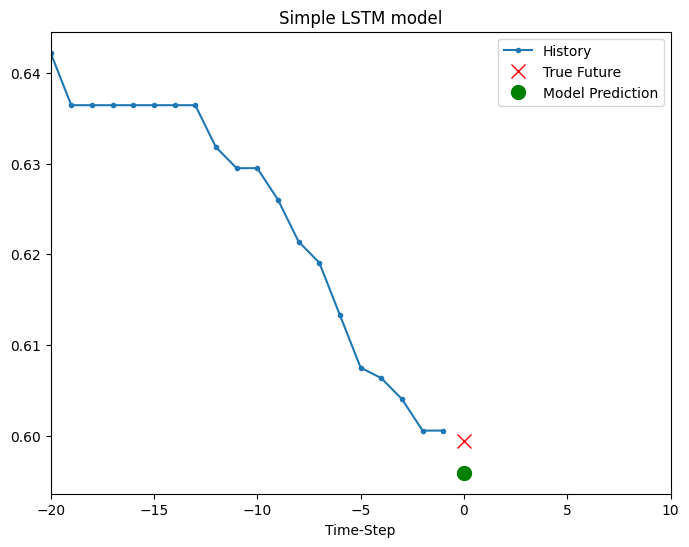

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


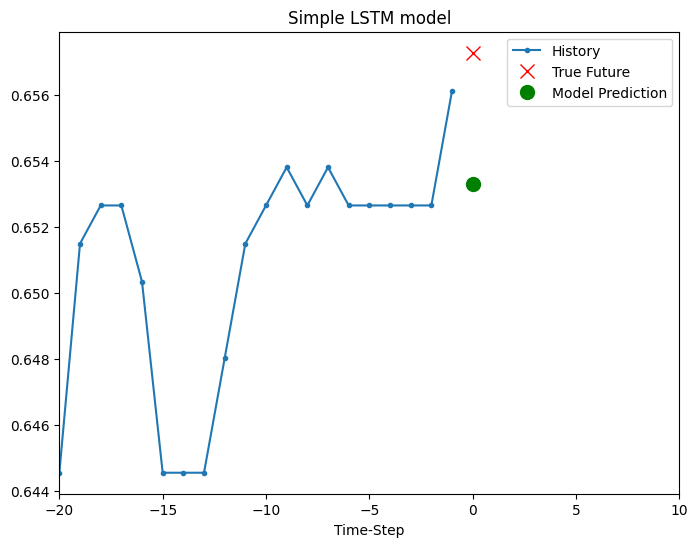

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


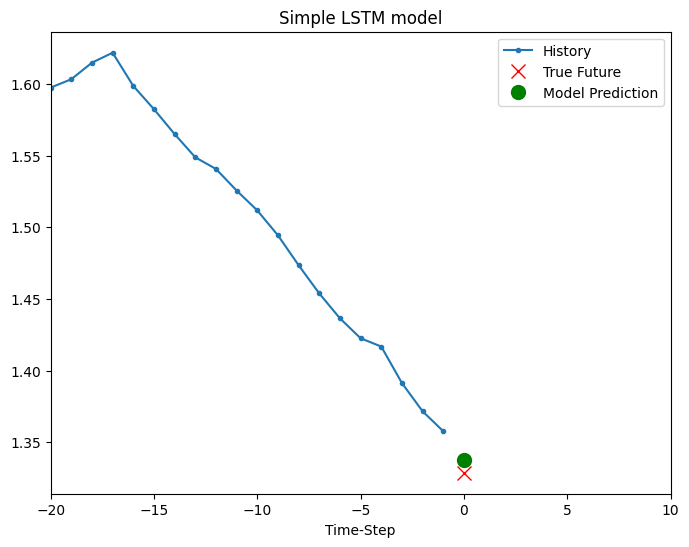

In [ ]:
for x, y in val_univariate.take(3):
  plot = show_plot([x[0].numpy(), y[0].numpy(),
                    simple_lstm_model.predict(x)[0]], 0, 'Simple LSTM model')

This looks better than the baseline. Now that you have seen the basics, let's move on to part two, where you will work with a multivariate time series.

##Part 2: Forecast a multivariate time series
The original dataset contains fourteen features. For simplicity, this section considers only three of the original fourteen. The features used are air temperature, atmospheric pressure, and air density.

To use more features, add their names to this list.

In [ ]:
features_considered = ['p (mbar)', 'T (degC)', 'rho (g/m**3)']
features = df[features_considered]
features.index = df['Date Time']
features

,p (mbar),T (degC),rho (g/m**3)
Date Time,,,
01.01.2009 00:10:00,996.52,-8.02,1307.75
01.01.2009 00:20:00,996.57,-8.41,1309.80
01.01.2009 00:30:00,996.53,-8.51,1310.24
01.01.2009 00:40:00,996.51,-8.31,1309.19
01.01.2009 00:50:00,996.51,-8.27,1309.00
...,...,...,...
31.12.2016 23:20:00,1000.07,-4.05,1292.98
31.12.2016 23:30:00,999.93,-3.35,1289.44
31.12.2016 23:40:00,999.82,-3.16,1288.39


Let's have a look at how each of these features vary across time.

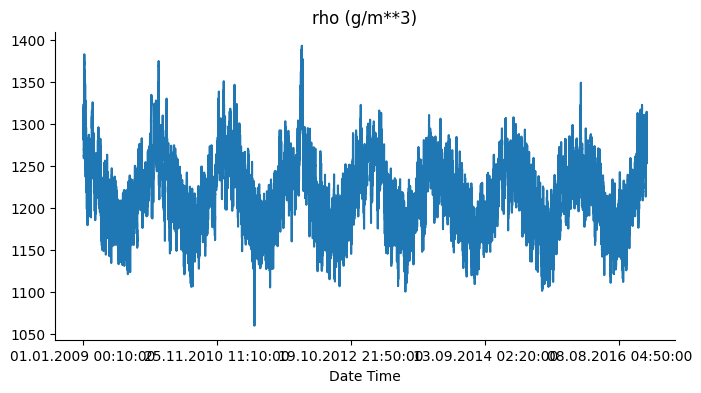

In [ ]:
from matplotlib import pyplot as plt
features['rho (g/m**3)'].plot(kind='line', figsize=(8, 4), title='rho (g/m**3)')
plt.gca().spines[['top', 'right']].set_visible(False)

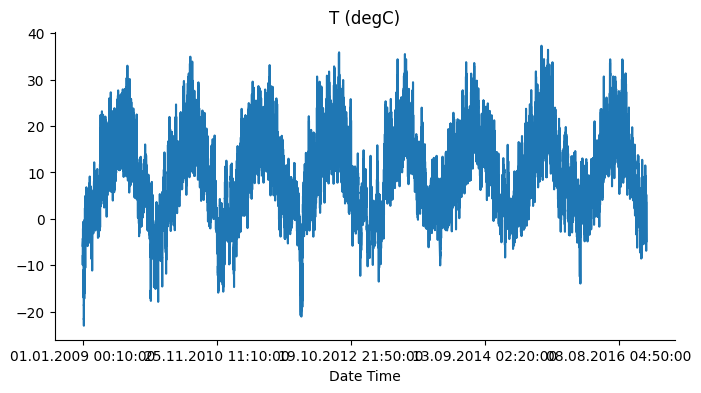

In [ ]:
from matplotlib import pyplot as plt
features['T (degC)'].plot(kind='line', figsize=(8, 4), title='T (degC)')
plt.gca().spines[['top', 'right']].set_visible(False)

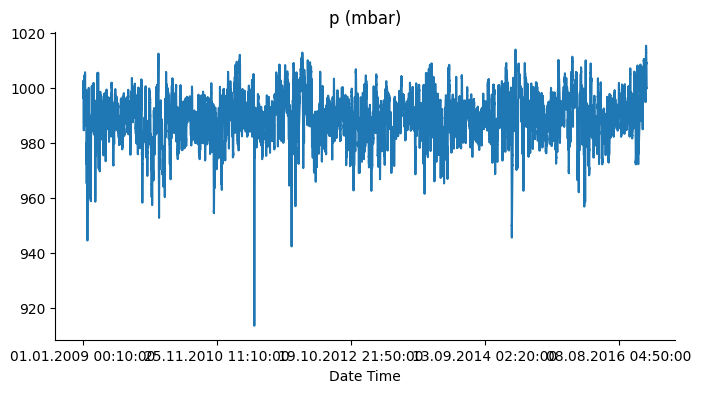

In [ ]:
from matplotlib import pyplot as plt
features['p (mbar)'].plot(kind='line', figsize=(8, 4), title='p (mbar)')
plt.gca().spines[['top', 'right']].set_visible(False)

array([<Axes: xlabel='Date Time'>, <Axes: xlabel='Date Time'>,
       <Axes: xlabel='Date Time'>], dtype=object)

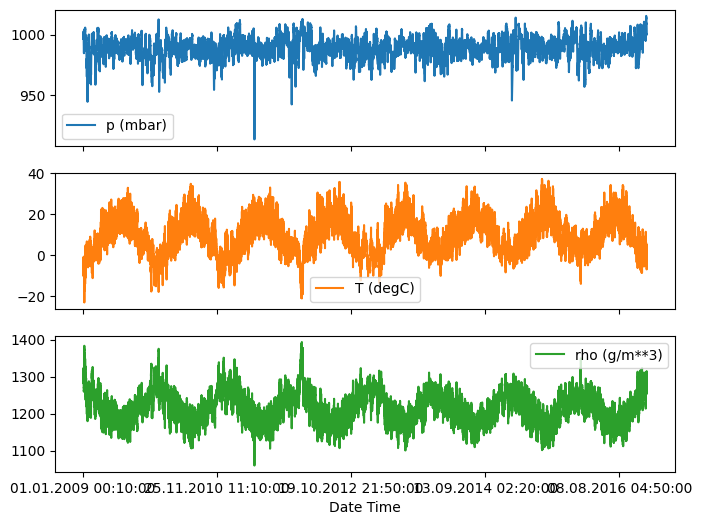

In [ ]:
features.plot(subplots=True)

As mentioned, the first step will be to standardize the dataset using the mean and standard deviation of the training data.

In [ ]:
dataset = features.values
data_mean = dataset[:TRAIN_SPLIT].mean(axis=0)
data_std = dataset[:TRAIN_SPLIT].std(axis=0)

In [ ]:
data_mean

array([ 988.65117607,    9.2332563 , 1216.40583777])

In [ ]:
data_std

array([ 8.23552219,  8.6367204 , 40.86842488])

In [ ]:
dataset = (dataset-data_mean)/data_std

In [ ]:
dataset.mean()

np.float64(0.028303359322306553)

In [ ]:
dataset.std()

np.float64(0.990116848347754)

###Single step model
In a single step setup, the model learns to predict a single point in the future based on some history provided.

The below function performs the same windowing task as above, however, here it samples the past observation based on the step size given.

In [ ]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In this tutorial, the network is shown data from the last five (5) days, i.e. 720 observations that are sampled every hour. The sampling is done every one hour since a drastic change is not expected within 60 minutes. Thus, 120 observation represent history of the last five days. For the single step prediction model, the label for a datapoint is the temperature 12 hours into the future. In order to create a label for this, the temperature after 72(12*6) observations is used.

In [ ]:
past_history = 720
future_target = 72
STEP = 6

x_train_single, y_train_single = multivariate_data(dataset, dataset[:, 1], 0,
                                                   TRAIN_SPLIT, past_history,
                                                   future_target, STEP,
                                                   single_step=True)
x_val_single, y_val_single = multivariate_data(dataset, dataset[:, 1],
                                               TRAIN_SPLIT, None, past_history,
                                               future_target, STEP,
                                               single_step=True)

In [ ]:
x_train_single.shape

(299280, 120, 3)

In [ ]:
# Let's look at a single data-point.
print ('Single window of past history : {}'.format(x_train_single[0].shape))

Single window of past history : (120, 3)


In [ ]:
train_data_single = tf.data.Dataset.from_tensor_slices((x_train_single, y_train_single))
train_data_single = train_data_single.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_single = tf.data.Dataset.from_tensor_slices((x_val_single, y_val_single))
val_data_single = val_data_single.batch(BATCH_SIZE).repeat()

In [ ]:
train_data_single

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 120, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [ ]:
single_step_model = tf.keras.models.Sequential()
single_step_model.add(tf.keras.layers.InputLayer((x_train_single.shape[-2:])))
single_step_model.add(tf.keras.layers.LSTM(32))
single_step_model.add(tf.keras.layers.Dense(1))

single_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(), loss='mae')
single_step_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Let's check out a sample prediction.
for x, y in val_data_single.take(1):
  print(single_step_model.predict(x).shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
(256, 1)


In [ ]:
single_step_history = single_step_model.fit(train_data_single, epochs=EPOCHS,
                                            steps_per_epoch=EVALUATION_INTERVAL,
                                            validation_data=val_data_single,
                                            validation_steps=50)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.3130 - val_loss: 0.2540
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.2614 - val_loss: 0.2401
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.2590 - val_loss: 0.2455
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.2555 - val_loss: 0.2376
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.2257 - val_loss: 0.2352
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.2372 - val_loss: 0.2597
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.2410 - val_loss: 0.2606
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.2449 - val_loss: 0.2555
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.2471 - val_loss: 0.2462
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.2406 - val_loss: 0.2372
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.2199 - val_loss: 0.2551
Epoch 12/20
200/200 ━━━━━━━━━━━━━

In [ ]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(len(loss))
  plt.figure()
  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()
  plt.show()

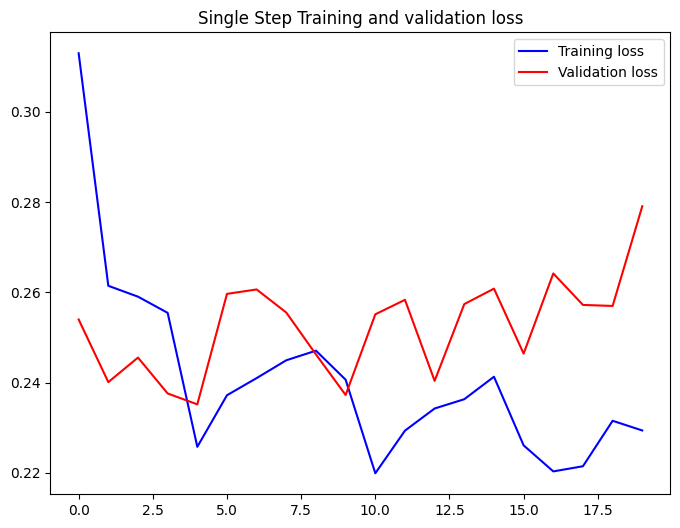

In [ ]:
plot_train_history(single_step_history,
                   'Single Step Training and validation loss')

###Predict a single step future
Now that the model is trained, let's make a few sample predictions. The model is given the history of three features over the past five days sampled every hour (120 data-points), since the goal is to predict the temperature, the plot only displays the past temperature. The prediction is made one day into the future (hence the gap between the history and prediction).

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


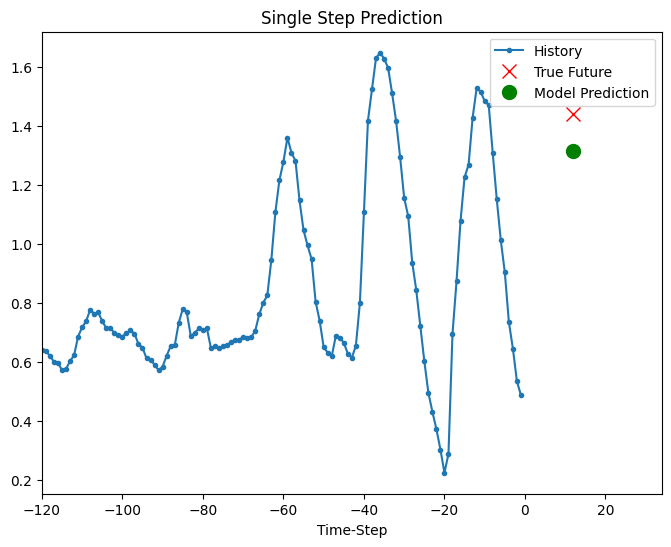

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


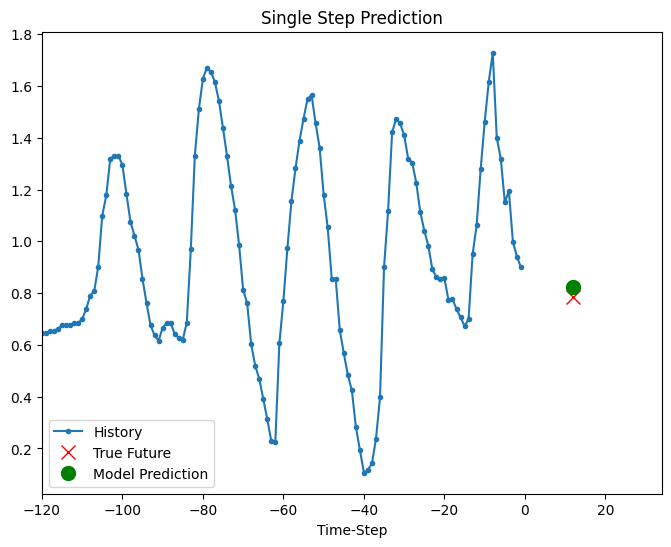

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


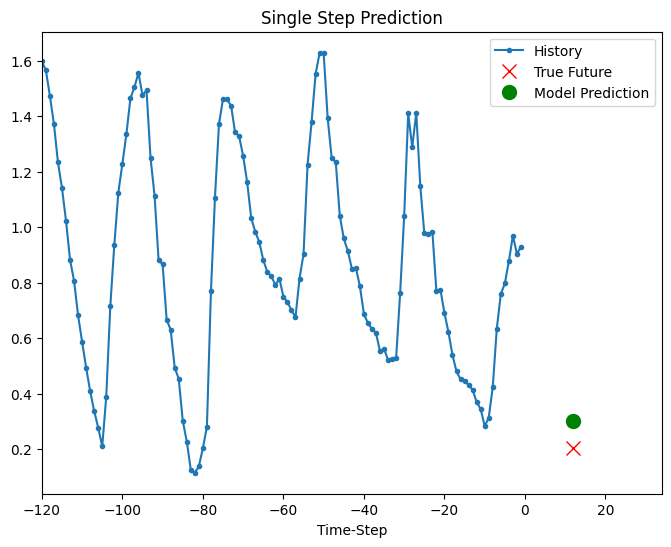

In [ ]:
for x, y in val_data_single.take(3):
  plot = show_plot([x[0][:, 1].numpy(), y[0].numpy(),
                    single_step_model.predict(x)[0]], 12,
                   'Single Step Prediction')

###Multi-Step model
In a multi-step prediction model, given a past history, the model needs to learn to predict a range of future values. Thus, unlike a single step model, where only a single future point is predicted, a multi-step model predict a sequence of the future.

For the multi-step model, the training data again consists of recordings over the past five days sampled every hour. However, here, the model needs to learn to predict the temperature for the next 12 hours. Since an obversation is taken every 10 minutes, the output is 72 predictions. For this task, the dataset needs to be prepared accordingly, thus the first step is just to create it again, but with a different target window.

In [ ]:
future_target = 72
x_train_multi, y_train_multi = multivariate_data(dataset, dataset[:, 1], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_multi, y_val_multi = multivariate_data(dataset, dataset[:, 1],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [ ]:
x_train_multi.shape

(299280, 120, 3)

In [ ]:
y_train_multi.shape

(299280, 72)

In [ ]:
# Let's check out a sample data-point.
print ('Single window of past history : {}'.format(x_train_multi[0].shape))
print ('Target temperature to predict : {}'.format(y_train_multi[0].shape))

Single window of past history : (120, 3)
Target temperature to predict : (72,)


In [ ]:
train_data_multi = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
train_data_multi = train_data_multi.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_multi = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
val_data_multi = val_data_multi.batch(BATCH_SIZE).repeat()

In [ ]:
train_data_multi

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 120, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None, 72), dtype=tf.float64, name=None))>

In [ ]:
# Plotting a sample data-point.
def multi_step_plot(history, true_future, prediction):
  plt.figure(figsize=(12, 6))
  num_in = create_time_steps(len(history))
  num_out = len(true_future)

  plt.plot(num_in, np.array(history[:, 1]), label='History')
  plt.plot(np.arange(num_out)/STEP, np.array(true_future), 'bo',
           label='True Future')
  if prediction.any():
    plt.plot(np.arange(num_out)/STEP, np.array(prediction), 'ro',
             label='Predicted Future')
  plt.legend(loc='upper left')
  plt.show()

In this plot and subsequent similar plots, the history and the future data are sampled every hour.

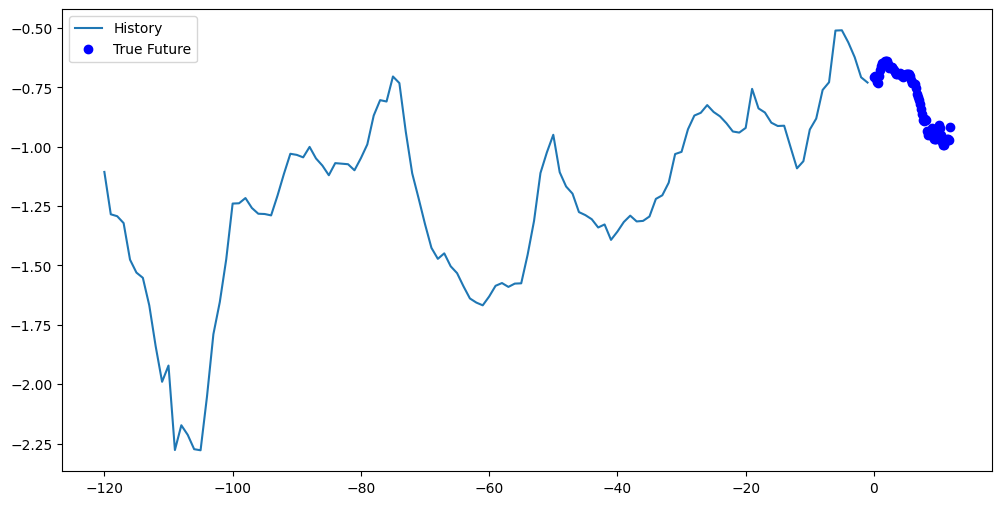

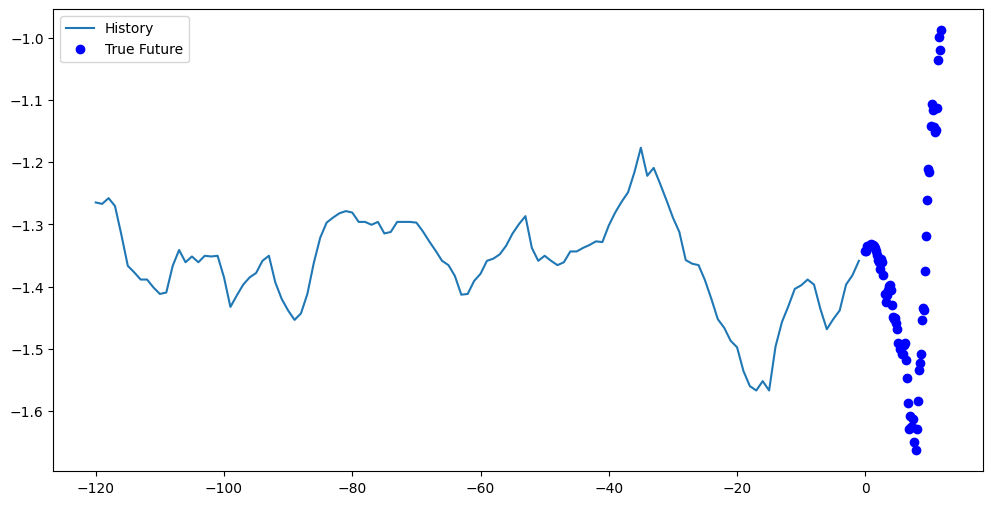

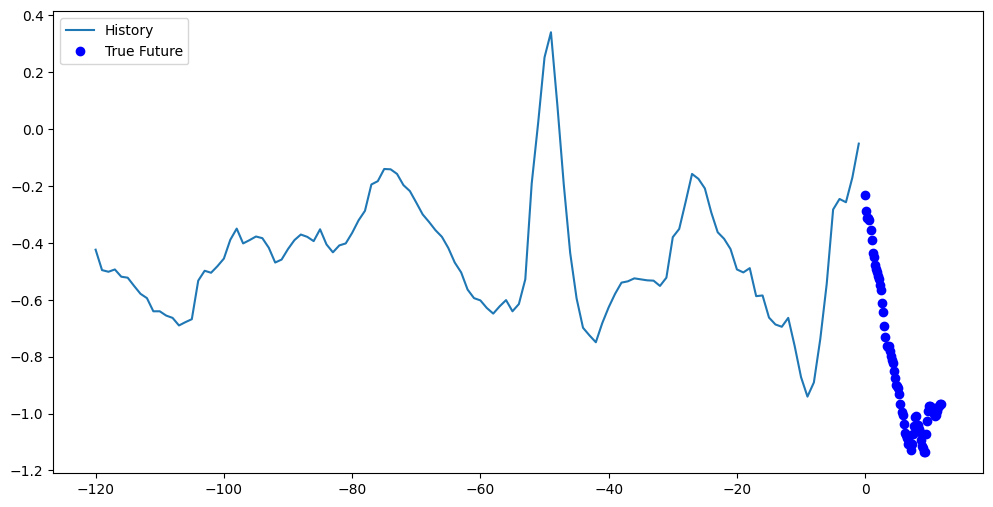

In [ ]:
for x, y in train_data_multi.take(3):
  multi_step_plot(x[0], y[0], np.array([0]))

Since the task here is a bit more complicated than the previous task, the model now consists of two LSTM layers. Finally, since 72 predictions are made, the dense layer outputs 72 predictions.

In [ ]:
multi_step_model = tf.keras.models.Sequential()
multi_step_model.add(tf.keras.layers.InputLayer((x_train_multi.shape[-2:])))
multi_step_model.add(tf.keras.layers.LSTM(32, return_sequences=True))
multi_step_model.add(tf.keras.layers.LSTM(16, activation='relu'))
multi_step_model.add(tf.keras.layers.Dense(72))

multi_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(clipvalue=1.0), loss='mae')
multi_step_model.summary()

In [ ]:
# Let's see how the model predicts before it trains.
for x, y in val_data_multi.take(1):
  print (multi_step_model.predict(x).shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
(256, 72)


In [ ]:
multi_step_history = multi_step_model.fit(train_data_multi, epochs=EPOCHS,
                                          steps_per_epoch=EVALUATION_INTERVAL,
                                          validation_data=val_data_multi,
                                          validation_steps=50)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - loss: 437435.4688 - val_loss: 0.3184
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.3412 - val_loss: 0.2683
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.2961 - val_loss: 0.2260
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.2357 - val_loss: 0.2132
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - loss: 0.1991 - val_loss: 0.1957
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - loss: 0.2108 - val_loss: 0.2155
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.2022 - val_loss: 0.2118
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - loss: 0.2006 - val_loss: 0.1915
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - loss: 0.2040 - val_loss: 0.1963
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - loss: 0.1937 - val_loss: 0.1883
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.1769 - val_loss: 0.1931
Epoch 12/20
200/200

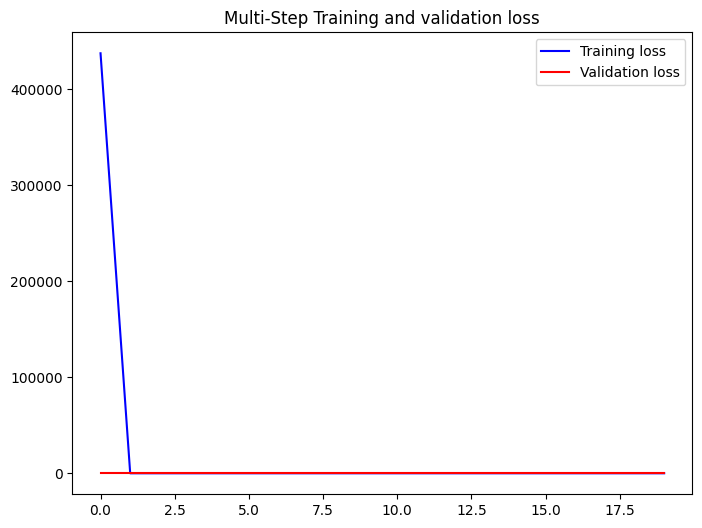

In [ ]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

In [ ]:
for x, y in val_data_multi.take(3):
  print(x.shape,y.shape)
  print(x[0].shape,y[0].shape)
  print(x[0,0], y[0,0])

(256, 120, 3) (256, 72)
(120, 3) (72,)
tf.Tensor([ 0.54748489  0.642228   -0.54922199], shape=(3,), dtype=float64) tf.Tensor(0.3689761336626933, shape=(), dtype=float64)
(256, 120, 3) (256, 72)
(120, 3) (72,)
tf.Tensor([ 0.48798653  0.6445437  -0.56439263], shape=(3,), dtype=float64) tf.Tensor(0.8645346098828947, shape=(), dtype=float64)
(256, 120, 3) (256, 72)
(120, 3) (72,)
tf.Tensor([ 0.14435319  1.5974517  -1.44820452], shape=(3,), dtype=float64) tf.Tensor(0.6850683392891302, shape=(), dtype=float64)


In [ ]:
y_hat=multi_step_model.predict(x)
print(y_hat.shape)
print(y_hat[0].shape)
print(y_hat[0,0])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
(256, 72)
(72,)
0.93809134


###Predict a multi-step future
Let's now have a look at how well your network has learnt to predict the future.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


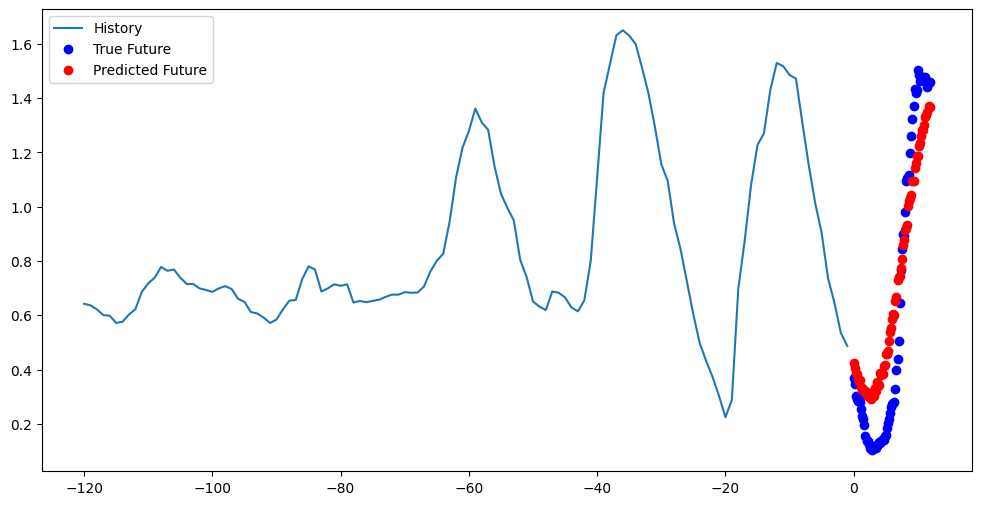

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


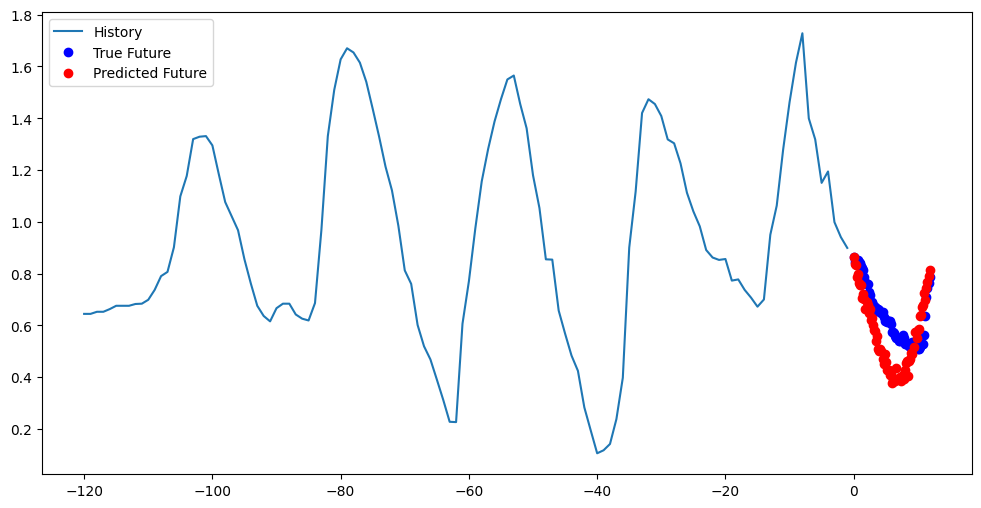

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


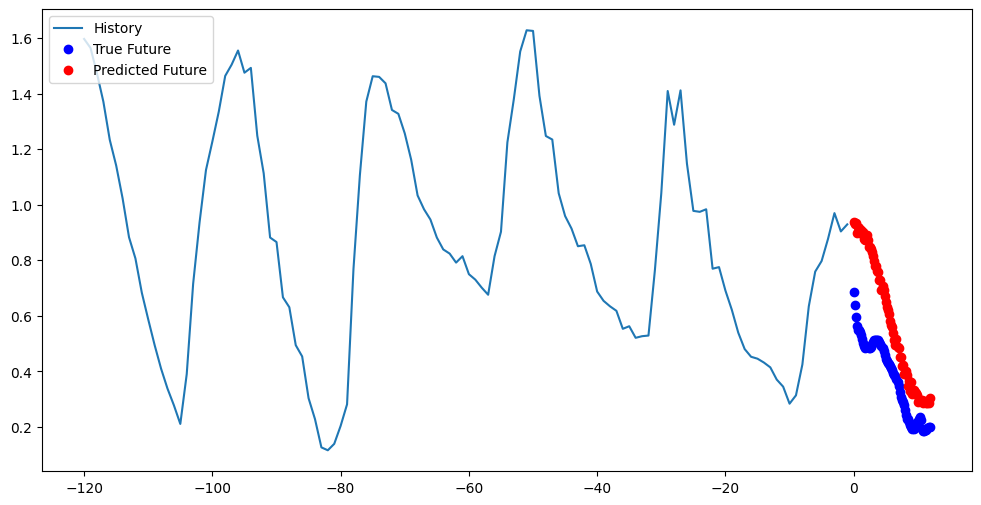

In [ ]:
for x, y in val_data_multi.take(3):
  multi_step_plot(x[0], y[0], multi_step_model.predict(x)[0])

##Referências
[1] https://www.kaggle.com/code/mineshjethva/time-series-forecasting-with-lstm-for-uni-multivar

[2] https://github.com/3p5ilon/ML-books/blob/main/Deep%20Learning%20with%20Python%2C%20Franc%CC%A7ois%20Chollet.pdf

[3] https://www.math.ttu.edu/~atrindad/tsdata/index.html

[4] https://www.kaggle.com/datasets/mvsfnig/time-series-pam

[5] https://questdb.com/

##Exercícios
1. Utilizar (baixar) um banco de dados de séries temporais que podem ser encontrados nas referências acima.
1. Efetuar previsões futuras pontuais e multi-step.
1. Comparar os resultados com os dados reais e Gerar métricas de avaliação das previsões
1. Modificar a arquitetura da rede recorrente e os hiperparâmetros para tentar obter melhores previsões